### Import libraries

In [2]:
%matplotlib inline
import os
import sys
import csv
import torch
import pathlib
import matplotlib
import numpy as np
import pandas as pd
import seaborn as sb

### Import Autoencoder class

In [4]:
folder_path = str(pathlib.Path().resolve().parents[0])
print("Folder path =", folder_path)
sys.path.append(folder_path + '/Notebooks/AE_class/')
from Conv_AE_weebots_downsampled import *

Folder path = C:\Users\specs\Desktop\Robotology\Repos\HPC-VTA_Autoencoder


### Check libraries versions

In [6]:
print(f"torch version: {torch.__version__}")
print(f"numpy version: {np.__version__}")
print(f"matplotlib version: {matplotlib.__version__}")
print(f"seaborn version: {sb.__version__}")

torch version: 2.2.1+cu121
numpy version: 1.26.4
matplotlib version: 3.8.0
seaborn version: 0.12.2


### Check GPU 

In [8]:
print("CUDA is available =", torch.cuda.is_available())
print("CUDA device count =", torch.cuda.device_count())
if torch.cuda.device_count() > 1:
    os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
#print(torch.cuda.current_device())
#print(torch.cuda.device(0))
print("CUDA device name =", torch.cuda.get_device_name(0))

CUDA is available = True
CUDA device count = 2
CUDA device name = NVIDIA RTX A5000


### Hyperparameters

In [10]:
#Experiment
model_training = True
save_plots = False

#Model
n_hidden = 200
batch_size = 256
num_epochs = 100
learning_rate = 1e-4
C_factor = 1e3
alpha = 1e5

#Others
trial_t = 0

peak_as_centroid=True
min_pix_cluster=0.02
max_pix_cluster=0.5
active_threshold=0.2

### Functions

In [12]:
def format_dataset(env):
    data_path = folder_path + '/Datasets/' + env
    csv_filename = data_path + "/data.csv"

    img_filename_list = os.listdir(data_path)
    num_images = len(img_filename_list) -1 

    return data_path, csv_filename, num_images
#####################################################################

def check_plot_folders(plot_folder_path, plot_foldername):
    folders = [name for name in os.listdir(plot_folder_path) if os.path.isdir(os.path.join(plot_folder_path, name))]
    if (plot_foldername in folders) == False:
        print('Creating new plot folder =', plot_foldername)
        os.makedirs(plot_folder_path + '/' + plot_foldername)
        
    return folders
#####################################################################

def check_model_folders(model_path, model_foldername):
    folders = [name for name in os.listdir(model_path) if os.path.isdir(os.path.join(model_path, name))]
    if (model_foldername in folders) == False:
        print('Creating new model folder =', model_foldername)
        os.makedirs(model_path + '/' + model_foldername)
        
    return folders
#####################################################################

def load_csv(csv_filename):
    data = pd.read_csv(csv_filename)
    data = data[:num_images]
    position = [] 
    pos_step = []
    orientation = []
    
    for i in range(len(data)):
        pos_step = [data.X[i], data.Y[i]]
        position.append(pos_step)
        z = data.Z[i]
        orientation.append(z)
        
    position = np.array(position)
    orientation = np.array(orientation)
    
    return data, position, orientation
#####################################################################

def save_training_loss(loss_csv_filename, loss):
    with open(loss_csv_filename, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(['Image_loss'])
    
        # If you want each element on a new line
        for item in loss:
            writer.writerow([item])
    print("Loss History saved at", loss_csv_filename)

### Dataset variables

In [14]:
envs = ['Tmaze_old1', 'Tmaze_old2', 'Tmaze_old3']
env = envs[0] #Choose environment index
data_path, csv_filename, num_images = format_dataset(env)

print("Dataset Environment =", env)
print("Num. Images in Dataset =", num_images)
print("Dataset Path =", data_path)
print("CSV path =    ", csv_filename)

Dataset Environment = Tmaze_old1
Num. Images in Dataset = 39998
Dataset Path = C:\Users\specs\Desktop\Robotology\Repos\HPC-VTA_Autoencoder/Datasets/Tmaze_old1
CSV path =     C:\Users\specs\Desktop\Robotology\Repos\HPC-VTA_Autoencoder/Datasets/Tmaze_old1/data.csv


### Model name

In [16]:
foldername = 'Control-Exp10-NEpisodes' + str(num_epochs) + '-NHidden' + str(n_hidden) + '-BSize' + str(batch_size) + '-C' + str(C_factor) + '-A' + str(alpha) + '-LR' + str(learning_rate)

model_folder_path = folder_path + '/Models/'
plot_folder_path = folder_path + '/Plots/'

check_model_folders(model_folder_path, foldername)
check_plot_folders(plot_folder_path, foldername)

model_folder_path = model_folder_path + foldername
plot_folder_path = plot_folder_path + foldername

loss_csv_filename = model_folder_path + '/loss_history.csv'

print("Model path =", model_folder_path)
print("Plot path  =", plot_folder_path)
print("Loss path  =", loss_csv_filename)

Creating new model folder = Control-Exp10-NEpisodes100-NHidden200-BSize256-C1000.0-A100000.0-LR0.0001
Creating new plot folder = Control-Exp10-NEpisodes100-NHidden200-BSize256-C1000.0-A100000.0-LR0.0001
Model path = C:\Users\specs\Desktop\Robotology\Repos\HPC-VTA_Autoencoder/Models/Control-Exp10-NEpisodes100-NHidden200-BSize256-C1000.0-A100000.0-LR0.0001
Plot path  = C:\Users\specs\Desktop\Robotology\Repos\HPC-VTA_Autoencoder/Plots/Control-Exp10-NEpisodes100-NHidden200-BSize256-C1000.0-A100000.0-LR0.0001
Loss path  = C:\Users\specs\Desktop\Robotology\Repos\HPC-VTA_Autoencoder/Models/Control-Exp10-NEpisodes100-NHidden200-BSize256-C1000.0-A100000.0-LR0.0001/loss_history.csv


### Import image dataset and CSV data

In [18]:
dataset = load_dataset(data_path)  # this array should have shape (n_samples, 3, 120, 160)
Tmaze0_data, Tmaze0_position, Tmaze0_orientation = load_csv(csv_filename)

print("Dataset Environment =", env)
print("Dataset Shape =", dataset.shape)
print("Position Shape =", Tmaze0_position.shape)
print()
Tmaze0_data

Dataset Environment = Tmaze_old1
Dataset Shape = (39998, 120, 160, 3)
Position Shape = (39998, 2)



,Trial_number,Trial_time,Frame_ID,Embedding,action,retrieved_action,X,Y,Z,Internal_states,RewardID,Reward_value,n_replays
0,0,1.024,1,[],"[0, 0]",False,-0.000008,-0.509500,270.045416,"[0.499, 0.999]",0,"[0, 0, 0, 0]",0
1,0,2.048,2,[],"[-0.79, 0.79]",False,-0.004842,-0.508203,300.623175,"[0.498, 0.998]",0,"[0, 0, 0, 0]",0
2,0,3.072,3,[],"[6.28, 4.71]",False,0.031163,-0.405354,271.754423,"[0.497, 0.997]",0,"[0, 0, 0, 0]",0
3,0,4.096,4,[],"[6.28, 6.28]",False,0.035498,-0.280885,272.135320,"[0.496, 0.996]",0,"[0, 0, 0, 0]",0
4,0,5.120,5,[],"[-0.79, 0.79]",False,0.030488,-0.279377,303.759316,"[0.495, 0.995]",0,"[0, 0, 0, 0]",0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
39993,75,180.224,39996,[],"[3.14, 1.57]",False,-0.155667,0.587166,162.917025,"[0.824, 0.324]",0,"[0, 0, 0, 0]",0
39994,75,181.248,39997,[],"[6.28, 5.5]",False,-0.266212,0.536343,145.677952,"[0.823, 0.323]",0,"[0, 0, 0, 0]",0
39995,75,182.272,39998,[],"[6.28, 6.28]",False,-0.369154,0.466171,145.791293,"[0.822, 0.322]",0,"[0, 0, 0, 0]",0
39996,75,183.296,39999,[],"[6.28, 6.28]",False,-0.472141,0.396160,145.791718,"[0.821, 0.321]",0,"[0, 0, 0, 0]",0


### Display example image

Image shape = (120, 160, 3)


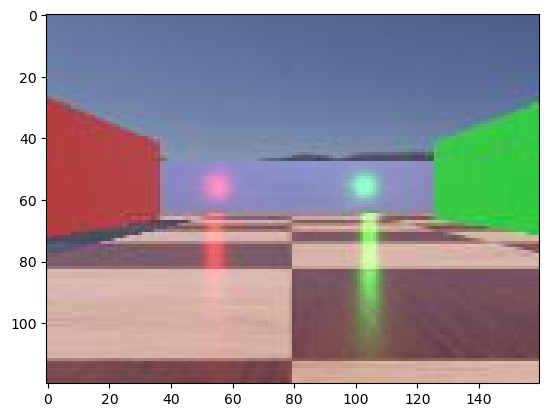

In [20]:
idx = 0
plt.imshow(dataset[idx])
print("Image shape =", dataset[idx].shape)

### Model training

In [22]:
if model_training == True:
    loss = []
    model = Conv_AE(n_hidden=n_hidden)
    train_loader = create_dataloader(dataset, batch_size=batch_size)

    #Save untrained model
    trial_t = 0
    model_filename =  env + '-Trial' + str(trial_t) + 'of' + str(num_epochs) + '-NHidden' + str(n_hidden) + '-BSize' + str(batch_size) + '-C' + str(C_factor) + '-A' + str(alpha) + '-LR' + str(learning_rate) + '.pth'
    model_path = model_folder_path + '/' + model_filename
    torch.save(model.state_dict(), model_path)
    
    for i in range(num_epochs):
        #Train model
        history, _ = train_autoencoder(model, train_loader, num_epochs=1, learning_rate=learning_rate, alpha=alpha, C_factor=C_factor)
        loss.append(history[0])

        #Save model
        trial_t = i + 1
        model_filename =  env + '-Trial' + str(trial_t) + 'of' + str(num_epochs) + '-NHidden' + str(n_hidden) + '-BSize' + str(batch_size) + '-C' + str(C_factor) + '-A' + str(alpha) + '-LR' + str(learning_rate) + '.pth'
        model_path = model_folder_path + '/' + model_filename
        torch.save(model.state_dict(), model_path)

Epoch 1/1, Loss: 0.0094: 100%|███████████████████████████████████████████████████████| 157/157 [00:15<00:00, 10.14it/s]


## Update dataset to next environment

In [24]:
env = envs[1]
data_path, csv_filename, num_images = format_dataset(env)
dataset = load_dataset(data_path)  # this array should have shape (n_samples, 3, 120, 160)

Tmaze1_data, Tmaze1_position, Tmaze1_orientation = load_csv(csv_filename)

print("New Environment =", env)
print("Num. Images in Dataset =", num_images)
print("Dataset Shape =", dataset.shape)
print("Position Shape =", Tmaze1_position.shape)
print()

New Environment = Tmaze_old2
Num. Images in Dataset = 39998
Dataset Shape = (39998, 120, 160, 3)
Position Shape = (39998, 2)



#### Display example image

Image shape = (120, 160, 3)


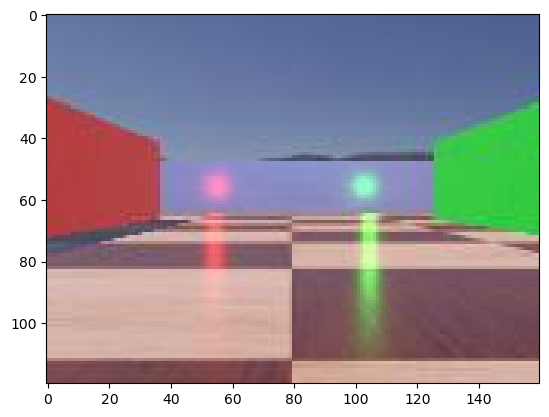

In [26]:
plt.imshow(dataset[idx])
print("Image shape =", dataset[idx].shape)

#### Model training

In [28]:
if model_training == True:
    train_loader = create_dataloader(dataset, batch_size=batch_size)
    for i in range(num_epochs):
        #Train model
        history, _ = train_autoencoder(model, train_loader, num_epochs=1, learning_rate=learning_rate, alpha=alpha, C_factor=C_factor)
        loss.append(history[0])

        #Save model
        trial_t = i + 1
        model_filename =  env + '-Trial' + str(trial_t) + 'of' + str(num_epochs) + '-NHidden' + str(n_hidden) + '-BSize' + str(batch_size) + '-C' + str(C_factor) + '-A' + str(alpha) + '-LR' + str(learning_rate) + '.pth'
        model_path = model_folder_path + '/' + model_filename
        torch.save(model.state_dict(), model_path)

Epoch 1/1, Loss: 0.0085: 100%|███████████████████████████████████████████████████████| 157/157 [00:15<00:00, 10.31it/s]


## Update dataset to next environment

In [30]:
env = envs[2]
data_path, csv_filename, num_images = format_dataset(env)
dataset = load_dataset(data_path)  # this array should have shape (n_samples, 3, 120, 160)

Tmaze2_data, Tmaze2_position, Tmaze2_orientation = load_csv(csv_filename)

print("New Environment =", env)
print("Num. Images in Dataset =", num_images)
print("Dataset Shape =", dataset.shape)
print("Position Shape =", Tmaze2_position.shape)
print()

New Environment = Tmaze_old3
Num. Images in Dataset = 39998
Dataset Shape = (39998, 120, 160, 3)
Position Shape = (39998, 2)



#### Display example image

Image shape = (120, 160, 3)


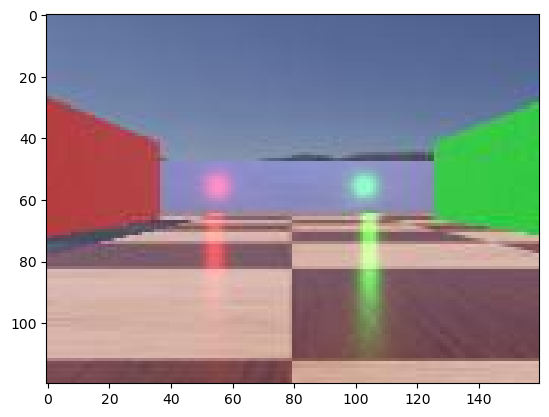

In [32]:
plt.imshow(dataset[idx])
print("Image shape =", dataset[idx].shape)

#### Model training

In [34]:
if model_training == True:
    train_loader = create_dataloader(dataset, batch_size=batch_size)
    for i in range(num_epochs):
        #Train model
        history, _ = train_autoencoder(model, train_loader, num_epochs=1, learning_rate=learning_rate, alpha=alpha, C_factor=C_factor)
        loss.append(history[0])

        #Save model
        trial_t = i + 1
        model_filename =  env + '-Trial' + str(trial_t) + 'of' + str(num_epochs) + '-NHidden' + str(n_hidden) + '-BSize' + str(batch_size) + '-C' + str(C_factor) + '-A' + str(alpha) + '-LR' + str(learning_rate) + '.pth'
        model_path = model_folder_path + '/' + model_filename
        torch.save(model.state_dict(), model_path)

Epoch 1/1, Loss: 0.0083: 100%|███████████████████████████████████████████████████████| 157/157 [00:15<00:00, 10.28it/s]


In [35]:
save_training_loss(loss_csv_filename, loss)

Loss History saved at C:\Users\specs\Desktop\Robotology\Repos\HPC-VTA_Autoencoder/Models/Control-Exp10-NEpisodes100-NHidden200-BSize256-C1000.0-A100000.0-LR0.0001/loss_history.csv


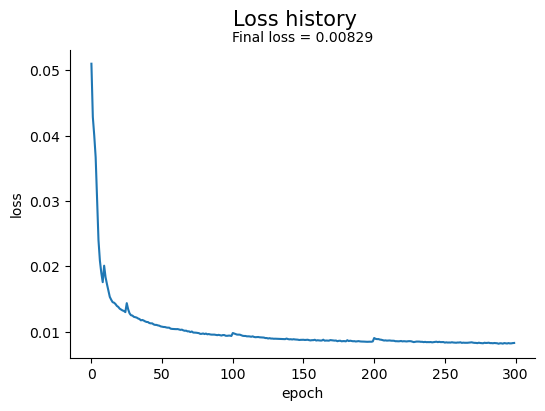

In [36]:
if model_training == True:
    fig = plt.figure(figsize=(6,4))
    plt.plot(loss)
    plt.xlabel('epoch')
    plt.ylabel('loss')
    sb.despine()
    plt.suptitle('Loss history', fontsize=15)
    plt.title('Final loss = ' + str(round(history[-1], 5)), fontsize=10)
    plt.show()
    if save_plots == True:
        fig.savefig(plot_folder_path + '/History_loss.pdf', format='pdf', bbox_inches='tight')
        fig.savefig(plot_folder_path + '/History_loss.png', format='png')

## Check Results (Last training episode)

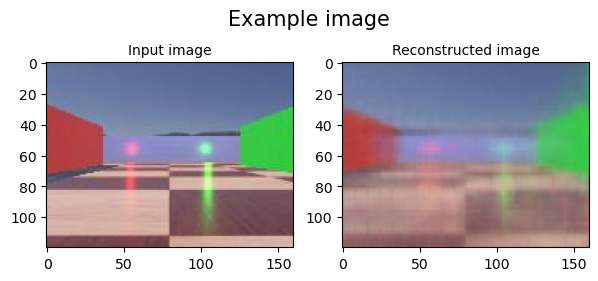

In [38]:
fig = plt.figure(figsize=(7,3))
plt.subplot(121)
plt.imshow(dataset[idx])
plt.suptitle('Example image', fontsize=15)
plt.title('Input image', fontsize=10)
plt.subplot(122)
plt.imshow(predict(dataset[idx], model))
plt.title('Reconstructed image', fontsize=10)

plt.show()
if save_plots == True:
    fig.savefig(plot_folder_path + '/Image_reconstruction.pdf', format='pdf', bbox_inches='tight')
    fig.savefig(plot_folder_path + '/Image_reconstruction.png', format='png')

In [39]:
embeddings = get_latent_vectors(dataset, model, batch_size=batch_size)

In [40]:
all_ratemaps = ratemaps(embeddings, Tmaze2_position, n_bins=50, filter_width=3)

In [41]:
plot_ratemaps(all_ratemaps[:100], plot_folder_path, save=save_plots)

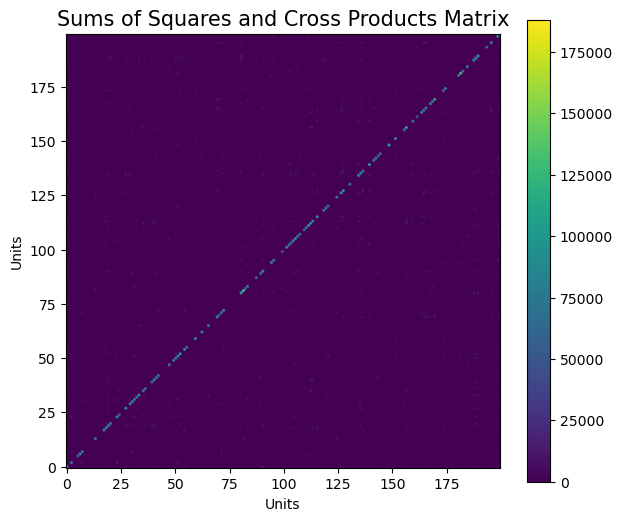

In [42]:
sscp = np.dot(embeddings.T, embeddings)

fig = plt.figure(figsize=(7,6))
plt.title('Sums of Squares and Cross Products Matrix', fontsize=15)
plt.imshow(sscp, origin='lower')
plt.xlabel('Units')
plt.ylabel('Units')
plt.colorbar()
plt.show()
if save_plots == True:
    fig.savefig(plot_folder_path + '/sscp.pdf', format='pdf', bbox_inches='tight')
    fig.savefig(plot_folder_path + '/sscp.png', format='png')

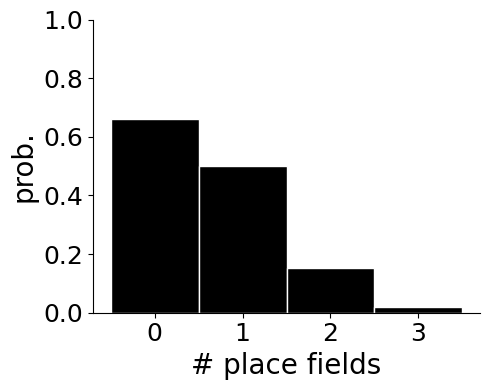

In [43]:
all_num_fields, centroids, sizes = stats_place_fields(all_ratemaps, peak_as_centroid=peak_as_centroid, min_pix_cluster=min_pix_cluster, max_pix_cluster=max_pix_cluster, active_threshold=active_threshold)
centroids_per_field, sizes_per_field = format_centroids(all_num_fields, centroids, sizes)
plot_place_field_hist(all_num_fields, plot_folder_path, save=save_plots)

## Check Results

In [45]:
save_plots = False

### Dataset and Model loading

In [47]:
env_idx = 0
env = envs[env_idx]
trial = 100

envs[env_idx]
data_path, csv_filename, num_images = format_dataset(env)
dataset = load_dataset(data_path)  # this array should have shape (n_samples, 3, 120, 160)

model_filename =  env + '-Trial' + str(trial) + 'of' + str(num_epochs) + '-NHidden' + str(n_hidden) + '-BSize' + str(batch_size) + '-C' + str(C_factor) + '-A' + str(alpha) + '-LR' + str(learning_rate) + '.pth'
model_path = model_folder_path + '/' + model_filename

model = Conv_AE(n_hidden=n_hidden)
model.load_state_dict(torch.load(model_path))
print("Model loaded:", model_path)

Model loaded: C:\Users\specs\Desktop\Robotology\Repos\HPC-VTA_Autoencoder/Models/Control-Exp10-NEpisodes100-NHidden200-BSize256-C1000.0-A100000.0-LR0.0001/Tmaze_old1-Trial100of100-NHidden200-BSize256-C1000.0-A100000.0-LR0.0001.pth


### Reconstruction performance

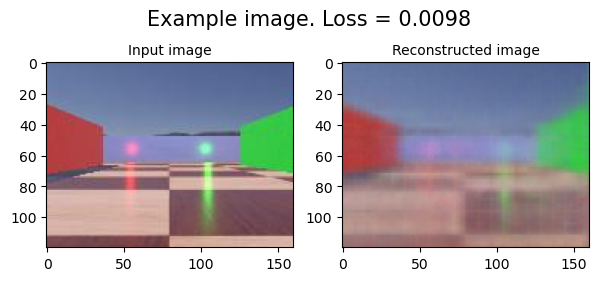

In [49]:
img_indx = 0
loss_idx = (env_idx*num_epochs) + trial
loss[loss_idx]

fig = plt.figure(figsize=(7,3))
plt.subplot(121)
plt.imshow(dataset[img_indx])
plt.suptitle('Example image. Loss = ' + str(round(loss[loss_idx],4)), fontsize=15)
plt.title('Input image', fontsize=10)
plt.subplot(122)
plt.imshow(predict(dataset[img_indx], model))
plt.title('Reconstructed image', fontsize=10)

plt.show()
if save_plots == True:
    fig.savefig(plot_folder_path + '/Image_reconstruction.pdf', format='pdf', bbox_inches='tight')
    fig.savefig(plot_folder_path + '/Image_reconstruction.png', format='png')

### Firing fields

In [51]:
embeddings = get_latent_vectors(dataset, model, batch_size=batch_size)

In [52]:
positions = [Tmaze0_position, Tmaze1_position, Tmaze2_position]
position = positions[env_idx]
all_ratemaps = ratemaps(embeddings, position, n_bins=50, filter_width=3)

In [53]:
plot_ratemaps(all_ratemaps[:100], plot_folder_path, save=save_plots)

### SSCP Matrix

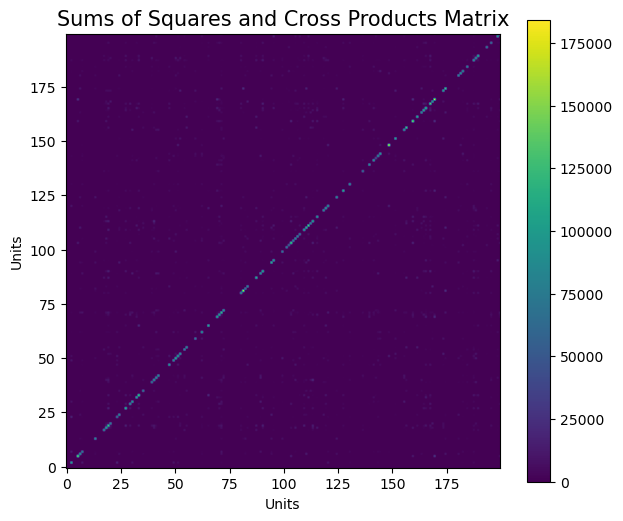

In [55]:
sscp = np.dot(embeddings.T, embeddings)

fig = plt.figure(figsize=(7,6))
plt.title('Sums of Squares and Cross Products Matrix', fontsize=15)
plt.imshow(sscp, origin='lower')
plt.xlabel('Units')
plt.ylabel('Units')
plt.colorbar()
plt.show()
if save_plots == True:
    fig.savefig(plot_folder_path + '/sscp.pdf', format='pdf', bbox_inches='tight')
    fig.savefig(plot_folder_path + '/sscp.png', format='png')

In [56]:
all_num_fields, centroids, sizes = stats_place_fields(all_ratemaps, peak_as_centroid=peak_as_centroid, min_pix_cluster=min_pix_cluster, max_pix_cluster=max_pix_cluster, active_threshold=active_threshold)
centroids_per_field, sizes_per_field = format_centroids(all_num_fields, centroids, sizes)

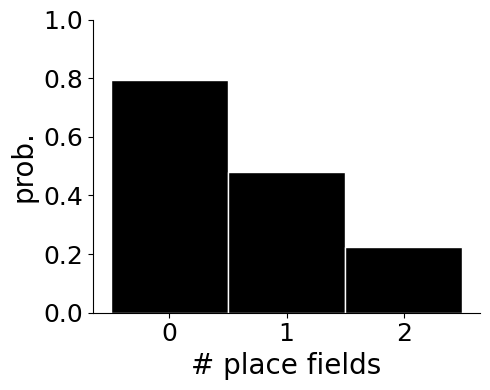

In [57]:
plot_place_field_hist(all_num_fields, plot_folder_path, save=save_plots)

Number of place fields = 0
Size of place fields = [[0, 0]]
YX position of place fields = [[0, 0]]


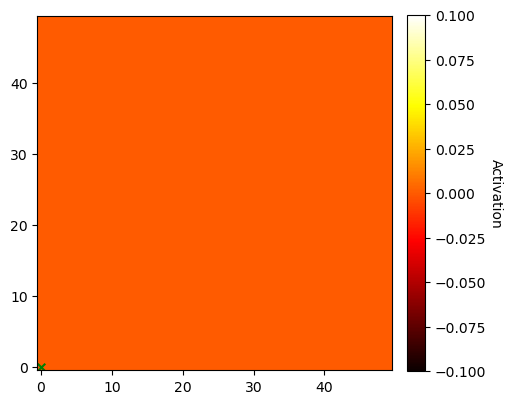

In [58]:
unit = 3
plot_single_ratemap_density(all_ratemaps, unit, all_num_fields, sizes_per_field, centroids_per_field, plot_folder_path, figsize=(5,5), save=save_plots)

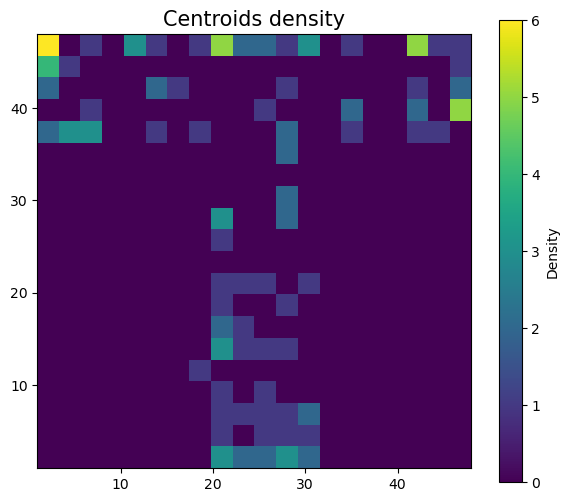

In [59]:
heatmap, xedges, yedges = np.histogram2d(centroids[:,1], centroids[:,0], bins=(20, 20))
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]

fig = plt.figure(figsize=(7,6))
plt.imshow(heatmap.T, extent=extent, origin='lower', cmap='viridis')
plt.colorbar(label='Density')
plt.title('Centroids density', fontsize=15)
if save_plots:
    fig.savefig(plot_folder_path + '/Centroids_density.pdf', format='pdf', bbox_inches='tight')
    fig.savefig(plot_folder_path + '/Centroids_density.png', format='png')
plt.show()

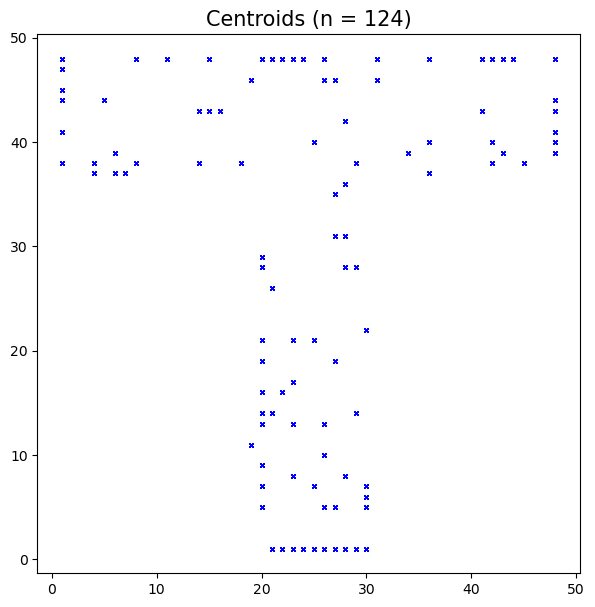

In [60]:
fig = plt.figure(figsize=(7,7))
for i in range(len(centroids)):
    plt.plot(centroids[:,1], centroids[:,0], 'bx', markersize=3)
plt.title("Centroids (n = " + str(len(centroids)) + ")", fontsize=15)
if save_plots:
    fig.savefig(plot_folder_path + '/Centroids.pdf', format='pdf', bbox_inches='tight')
    fig.savefig(plot_folder_path + '/Centroids.png', format='png')
plt.show()

In [61]:
max_fields = np.max(all_num_fields)

In [62]:
zero_pf = (np.unique(all_num_fields, return_counts=True)[1][0] / n_hidden) * 100
one_pf = (np.unique(all_num_fields, return_counts=True)[1][1] / n_hidden) * 100
two_pf = (np.unique(all_num_fields, return_counts=True)[1][2] / n_hidden) * 100
three_pf = (np.unique(all_num_fields, return_counts=True)[1][3] / n_hidden) * 100

categories = ['0', '1', '2', '3'] #
values = [zero_pf, one_pf, two_pf, three_pf] #

fig = plt.figure(figsize=(7,6))
plt.bar(categories, values)
plt.title('Percentaje of place fields', fontsize=15)
plt.xlabel('Place fields')
plt.ylabel('% of units')
if save_plots:
    fig.savefig(plot_folder_path + '/place_field_histogram.pdf', format='pdf', bbox_inches='tight')
    fig.savefig(plot_folder_path + '/place_field_histogram.png', format='png')
plt.show()

IndexError: index 3 is out of bounds for axis 0 with size 3

In [ ]:
polarmaps = polarmaps(embeddings, Tmaze2_orientation)
plot_polarmaps(polarmaps, plot_folder_path, save=save_plots)

In [ ]:
batch_training = False

In [ ]:
if batch_training == True:
    num_epochs = 100
    total_experiments = 10
    starting_experiment = 4
    current_exp = starting_experiment
    
    envs = ['Tmaze_old1', 'Tmaze_old2', 'Tmaze_old3']
    
    
    while current_exp <= total_experiments:
        model_folder_path = folder_path + '/Models/'
        plot_folder_path = folder_path + '/Plots/'
        print()
        print('---------- ---------- ---------- ---------- ----------')
        print('STARTING EXPERIMENT', str(current_exp))
        
        env = envs[0]
        data_path, csv_filename, num_images = format_dataset(env)
        foldername = 'Control-Exp' + str(current_exp) + '-NEpisodes' + str(num_epochs) + '-NHidden' + str(n_hidden) + '-BSize' + str(batch_size) + '-C' + str(C_factor) + '-A' + str(alpha) + '-LR' + str(learning_rate)
    
        check_model_folders(model_folder_path, foldername)
        check_plot_folders(plot_folder_path, foldername)
    
        model_folder_path = model_folder_path + foldername
        plot_folder_path = plot_folder_path + foldername
        loss_csv_filename = model_folder_path + '/loss_history.csv'
    
    
        ################# TRAINING PHASE 1 #################
        dataset = load_dataset(data_path)  # this array should have shape (n_samples, 3, 120, 160)
        Tmaze0_data, Tmaze0_position, Tmaze0_orientation = load_csv(csv_filename)
    
        loss = []
        model = Conv_AE(n_hidden=n_hidden)
        train_loader = create_dataloader(dataset, batch_size=batch_size)
        
        trial_t = 0
        model_filename =  env + '-Trial' + str(trial_t) + 'of' + str(num_epochs) + '-NHidden' + str(n_hidden) + '-BSize' + str(batch_size) + '-C' + str(C_factor) + '-A' + str(alpha) + '-LR' + str(learning_rate) + '.pth'
        model_path = model_folder_path + '/' + model_filename
        torch.save(model.state_dict(), model_path)
    
        for i in range(num_epochs):
            #Train model
            history, _ = train_autoencoder(model, train_loader, num_epochs=1, learning_rate=learning_rate, alpha=alpha, C_factor=C_factor)
            loss.append(history[0])
    
            #Save model
            trial_t = i + 1
            model_filename =  env + '-Trial' + str(trial_t) + 'of' + str(num_epochs) + '-NHidden' + str(n_hidden) + '-BSize' + str(batch_size) + '-C' + str(C_factor) + '-A' + str(alpha) + '-LR' + str(learning_rate) + '.pth'
            model_path = model_folder_path + '/' + model_filename
            torch.save(model.state_dict(), model_path)
    
    
        ################# TRAINING PHASE 2 #################
        env = envs[1]
        data_path, csv_filename, num_images = format_dataset(env)
        dataset = load_dataset(data_path)  # this array should have shape (n_samples, 3, 120, 160)
        
        Tmaze1_data, Tmaze1_position, Tmaze1_orientation = load_csv(csv_filename)
        train_loader = create_dataloader(dataset, batch_size=batch_size)
        
        for i in range(num_epochs):
            history, _ = train_autoencoder(model, train_loader, num_epochs=1, learning_rate=learning_rate, alpha=alpha, C_factor=C_factor)
            loss.append(history[0])
    
            trial_t = i + 1
            model_filename =  env + '-Trial' + str(trial_t) + 'of' + str(num_epochs) + '-NHidden' + str(n_hidden) + '-BSize' + str(batch_size) + '-C' + str(C_factor) + '-A' + str(alpha) + '-LR' + str(learning_rate) + '.pth'
            model_path = model_folder_path + '/' + model_filename
            torch.save(model.state_dict(), model_path)
    
        
        ################# TRAINING PHASE 3 #################
        env = envs[2]
        data_path, csv_filename, num_images = format_dataset(env)
        dataset = load_dataset(data_path)  # this array should have shape (n_samples, 3, 120, 160)
        
        Tmaze2_data, Tmaze2_position, Tmaze2_orientation = load_csv(csv_filename)
        train_loader = create_dataloader(dataset, batch_size=batch_size)
        
        for i in range(num_epochs):
            history, _ = train_autoencoder(model, train_loader, num_epochs=1, learning_rate=learning_rate, alpha=alpha, C_factor=C_factor)
            loss.append(history[0])
    
            trial_t = i + 1
            model_filename =  env + '-Trial' + str(trial_t) + 'of' + str(num_epochs) + '-NHidden' + str(n_hidden) + '-BSize' + str(batch_size) + '-C' + str(C_factor) + '-A' + str(alpha) + '-LR' + str(learning_rate) + '.pth'
            model_path = model_folder_path + '/' + model_filename
            torch.save(model.state_dict(), model_path)
    
        save_training_loss(loss_csv_filename, loss)
        current_exp += 1